**Minnesota actual baseline**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

player_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_player_boxscores/player_box_2026.parquet"
team_url = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_nba_team_boxscores/team_box_2026.parquet"

players = pd.read_parquet(player_url)
teams = pd.read_parquet(team_url)

special_games = [
    "401838140",
    "401838141",
    "401838143",
    "401809839"
]

players["game_id"] = players["game_id"].astype(str)
teams["game_id"] = teams["game_id"].astype(str)

players_rs = players[
    (players["season"] == 2026) &
    (players["season_type"] == 2) &
    (~players["game_id"].isin(special_games))
].copy()

teams_rs = teams[
    (teams["season"] == 2026) &
    (teams["season_type"] == 2) &
    (~teams["game_id"].isin(special_games))
].copy()

wolves = players_rs[
    players_rs["team_abbreviation"] == "MIN"
].copy()

wolves_team = teams_rs[
    teams_rs["team_abbreviation"] == "MIN"
].copy()

wolves_summary = (
    wolves
    .groupby("athlete_display_name")
    .agg(
        GP=("game_id", "nunique"),
        MPG=("minutes", "mean"),
        PPG=("points", "mean"),
        APG=("assists", "mean"),
        RPG=("rebounds", "mean"),
        FGA=("field_goals_attempted", "mean"),
        ThreePA=("three_point_field_goals_attempted", "mean"),
        FTA=("free_throws_attempted", "mean"),
        TOV=("turnovers", "mean")
    )
    .reset_index()
)

wolves_team["Possessions"] = (
    wolves_team["field_goals_attempted"]
    + 0.44 * wolves_team["free_throws_attempted"]
    - wolves_team["offensive_rebounds"]
    + wolves_team["turnovers"]
)

wolves_team["ORTG"] = (
    wolves_team["team_score"]
    / wolves_team["Possessions"]
) * 100

wolves_baseline = pd.Series({
    "Games": len(wolves_team),
    "PPG": wolves_team["team_score"].mean(),
    "ORTG": wolves_team["ORTG"].mean(),
    "FGA": wolves_team["field_goals_attempted"].mean(),
    "3PA": wolves_team["three_point_field_goals_attempted"].mean(),
    "FTA": wolves_team["free_throws_attempted"].mean(),
    "AST": wolves_team["assists"].mean(),
    "TOV": wolves_team["turnovers"].mean(),
    "Possessions": wolves_team["Possessions"].mean()
})

wolves_baseline.round(2)

,0
Games,82.00
PPG,118.00
ORTG,114.90
FGA,88.54
3PA,37.18
FTA,25.27
AST,26.07
TOV,14.12
Possessions,102.72


**Existing offensive structure**

In [ ]:
primary_creators = [
    "Anthony Edwards",
    "Julius Randle"
]

secondary_perimeter = [
    "Ayo Dosunmu",
    "Donte DiVincenzo",
    "Mike Conley"
]

wolves_primary = wolves_summary[
    wolves_summary["athlete_display_name"].isin(primary_creators)
].copy()

wolves_secondary = wolves_summary[
    wolves_summary["athlete_display_name"].isin(secondary_perimeter)
].copy()

primary_totals = pd.Series({
    "PPG": wolves_primary["PPG"].sum(),
    "APG": wolves_primary["APG"].sum(),
    "FGA": wolves_primary["FGA"].sum(),
    "3PA": wolves_primary["ThreePA"].sum(),
    "FTA": wolves_primary["FTA"].sum(),
    "TOV": wolves_primary["TOV"].sum()
})

secondary_totals = pd.Series({
    "PPG": wolves_secondary["PPG"].sum(),
    "APG": wolves_secondary["APG"].sum(),
    "FGA": wolves_secondary["FGA"].sum(),
    "3PA": wolves_secondary["ThreePA"].sum(),
    "FTA": wolves_secondary["FTA"].sum(),
    "TOV": wolves_secondary["TOV"].sum()
})

structure = pd.DataFrame({
    "Group": [
        "Anthony Edwards",
        "Julius Randle",
        "Secondary perimeter"
    ],
    "PPG": [
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Anthony Edwards",
            "PPG"
        ].iloc[0],
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Julius Randle",
            "PPG"
        ].iloc[0],
        secondary_totals["PPG"]
    ],
    "APG": [
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Anthony Edwards",
            "APG"
        ].iloc[0],
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Julius Randle",
            "APG"
        ].iloc[0],
        secondary_totals["APG"]
    ],
    "FGA": [
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Anthony Edwards",
            "FGA"
        ].iloc[0],
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Julius Randle",
            "FGA"
        ].iloc[0],
        secondary_totals["FGA"]
    ],
    "3PA": [
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Anthony Edwards",
            "ThreePA"
        ].iloc[0],
        wolves_primary.loc[
            wolves_primary["athlete_display_name"] == "Julius Randle",
            "ThreePA"
        ].iloc[0],
        secondary_totals["3PA"]
    ]
})

structure.round(2)

,Group,PPG,APG,FGA,3PA
0,Anthony Edwards,28.80,3.70,20.18,8.43
1,Julius Randle,21.10,5.04,15.28,4.38
2,Secondary perimeter,31.11,10.27,25.04,14.55


**LaMelo actual 2025–26 production**

In [ ]:
lamelo_games = players_rs[
    players_rs["athlete_display_name"].eq("LaMelo Ball")
].copy()

lamelo_actual = pd.Series({
    "GP": lamelo_games["game_id"].nunique(),
    "MPG": lamelo_games["minutes"].mean(),
    "PPG": lamelo_games["points"].mean(),
    "APG": lamelo_games["assists"].mean(),
    "RPG": lamelo_games["rebounds"].mean(),
    "FGA": lamelo_games["field_goals_attempted"].mean(),
    "3PA": lamelo_games["three_point_field_goals_attempted"].mean(),
    "FTA": lamelo_games["free_throws_attempted"].mean(),
    "TOV": lamelo_games["turnovers"].mean()
})

lamelo_actual.round(2)

,0
GP,72.00
MPG,27.99
PPG,20.07
APG,7.14
RPG,4.82
FGA,17.28
3PA,10.28
FTA,2.49
TOV,2.81


**LaMelo tracking-based creation profile**

In [ ]:
lamelo_tracking = pd.Series({
    "Potential_AST": 11.6,
    "Drives": 13.4,
    "Drive_PTS": 6.4,
    "Pullup_3PA": 5.6,
    "Pullup_3P%": 36.8,
    "Passes_Made": 48.8,
    "Passes_Received": 70.6,
    "Secondary_AST": 1.1,
    "AST_Points_Created": 18.6,
    "AST_Adjusted": 8.8
})

lamelo_tracking

,0
Potential_AST,11.6
Drives,13.4
Drive_PTS,6.4
Pullup_3PA,5.6
Pullup_3P%,36.8
Passes_Made,48.8
Passes_Received,70.6
Secondary_AST,1.1
AST_Points_Created,18.6
AST_Adjusted,8.8


**LaMelo EPM profile**

In [ ]:
epm_url = "https://dunksandthrees.com/epm"

epm_tables = pd.read_html(epm_url)
epm = epm_tables[0].copy()

epm.columns = [
    f"{level_0}_{level_1}"
    for level_0, level_1 in epm.columns
]

player_col = "Filters_Unnamed: 0_level_1"

lamelo_row = epm[
    epm[player_col]
    .astype(str)
    .str.startswith("LaMelo Ball", na=False)
].iloc[0]

def first_number(x):
    match = re.search(
        r"[-+]?\d+(?:\.\d+)?",
        str(x)
    )
    return float(match.group()) if match else np.nan

lamelo_epm = pd.Series({
    "MPG": first_number(lamelo_row["ROLE_MPG"]),
    "USG": first_number(lamelo_row["ROLE_USG"]),
    "OFF_EPM": first_number(lamelo_row["EST +/-_OFF"]),
    "DEF_EPM": first_number(lamelo_row["EST +/-_DEF"]),
    "EPM": first_number(lamelo_row["EST +/-_EPM"]),
    "TS%": first_number(lamelo_row["SCORING_TS%"]),
    "3P%": first_number(lamelo_row["SHOOTING_3P%"]),
    "AST_Rate": first_number(lamelo_row["HANDLE_AST"]),
    "TOV_Rate": first_number(lamelo_row["HANDLE_TOV"])
})

lamelo_epm

,0
MPG,29.7
USG,30.9
OFF_EPM,5.9
DEF_EPM,0.8
EPM,5.1
TS%,55.4
3P%,36.5
AST_Rate,11.5
TOV_Rate,4.7


**28/30/32-minute LaMelo workload scenarios**

In [ ]:
scenario_minutes = [28, 30, 32]

lamelo_scenarios = pd.DataFrame({
    "Minutes": scenario_minutes
})

for stat in [
    "PPG",
    "APG",
    "RPG",
    "FGA",
    "3PA",
    "FTA",
    "TOV"
]:
    lamelo_scenarios[stat] = (
        lamelo_actual[stat]
        * lamelo_scenarios["Minutes"]
        / lamelo_actual["MPG"]
    )

lamelo_scenarios.round(2)

,Minutes,PPG,APG,RPG,FGA,3PA,FTA,TOV
0,28,20.08,7.14,4.82,17.29,10.28,2.49,2.81
1,30,21.51,7.65,5.17,18.52,11.02,2.67,3.01
2,32,22.95,8.16,5.51,19.76,11.75,2.84,3.21


**Workload redistribution assumptions**

In [ ]:
redistribution_levels = [0.20, 0.30, 0.40]

redistribution = pd.DataFrame({
    "Redistribution": redistribution_levels
})

redistribution["Label"] = [
    "Low",
    "Base",
    "High"
]

redistribution

,Redistribution,Label
0,0.2,Low
1,0.3,Base
2,0.4,High


**Distribution of absorbed workload**

In [ ]:
source_splits = pd.DataFrame({
    "Scenario": [
        "Low secondary / high Randle",
        "Base",
        "High secondary / low Randle"
    ],
    "Secondary_Share": [
        0.65,
        0.75,
        0.85
    ]
})

source_splits["Randle_Share"] = (
    1 - source_splits["Secondary_Share"]
)

source_splits

,Scenario,Secondary_Share,Randle_Share
0,Low secondary / high Randle,0.65,0.35
1,Base,0.75,0.25
2,High secondary / low Randle,0.85,0.15


**Building the offensive workload pool**

In [ ]:
workload_pool = pd.Series({
    "Randle_PPG": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "PPG"
    ].iloc[0],

    "Randle_APG": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "APG"
    ].iloc[0],

    "Randle_FGA": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "FGA"
    ].iloc[0],

    "Randle_3PA": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "ThreePA"
    ].iloc[0],

    "Randle_FTA": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "FTA"
    ].iloc[0],

    "Randle_TOV": wolves_primary.loc[
        wolves_primary["athlete_display_name"] == "Julius Randle",
        "TOV"
    ].iloc[0],

    "Secondary_PPG": secondary_totals["PPG"],
    "Secondary_APG": secondary_totals["APG"],
    "Secondary_FGA": secondary_totals["FGA"],
    "Secondary_3PA": secondary_totals["3PA"],
    "Secondary_FTA": secondary_totals["FTA"],
    "Secondary_TOV": secondary_totals["TOV"]
})

workload_pool.round(2)

,0
Randle_PPG,21.10
Randle_APG,5.04
Randle_FGA,15.28
Randle_3PA,4.38
Randle_FTA,6.28
Randle_TOV,2.75
Secondary_PPG,31.11
Secondary_APG,10.27
Secondary_FGA,25.04
Secondary_3PA,14.55


**Modeling the 9 workload scenarios**

In [ ]:
scenario_rows = []

for _, lamelo in lamelo_scenarios.iterrows():

    for _, redistribution_row in redistribution.iterrows():

        for _, split in source_splits.iterrows():

            redistribution_rate = redistribution_row["Redistribution"]
            secondary_share = split["Secondary_Share"]
            randle_share = split["Randle_Share"]

            displaced_randle_ppg = (
                workload_pool["Randle_PPG"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_ppg = (
                workload_pool["Secondary_PPG"]
                * redistribution_rate
                * secondary_share
            )

            displaced_randle_apg = (
                workload_pool["Randle_APG"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_apg = (
                workload_pool["Secondary_APG"]
                * redistribution_rate
                * secondary_share
            )

            displaced_randle_fga = (
                workload_pool["Randle_FGA"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_fga = (
                workload_pool["Secondary_FGA"]
                * redistribution_rate
                * secondary_share
            )

            displaced_randle_3pa = (
                workload_pool["Randle_3PA"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_3pa = (
                workload_pool["Secondary_3PA"]
                * redistribution_rate
                * secondary_share
            )

            displaced_randle_fta = (
                workload_pool["Randle_FTA"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_fta = (
                workload_pool["Secondary_FTA"]
                * redistribution_rate
                * secondary_share
            )

            displaced_randle_tov = (
                workload_pool["Randle_TOV"]
                * redistribution_rate
                * randle_share
            )

            displaced_secondary_tov = (
                workload_pool["Secondary_TOV"]
                * redistribution_rate
                * secondary_share
            )

            scenario_rows.append({
                "LaMelo_Minutes": lamelo["Minutes"],
                "Redistribution": redistribution_rate,
                "Secondary_Share": secondary_share,
                "Randle_Share": randle_share,

                "LaMelo_PPG": lamelo["PPG"],
                "LaMelo_APG": lamelo["APG"],
                "LaMelo_FGA": lamelo["FGA"],
                "LaMelo_3PA": lamelo["3PA"],
                "LaMelo_FTA": lamelo["FTA"],
                "LaMelo_TOV": lamelo["TOV"],

                "Displaced_PPG": (
                    displaced_randle_ppg
                    + displaced_secondary_ppg
                ),

                "Displaced_APG": (
                    displaced_randle_apg
                    + displaced_secondary_apg
                ),

                "Displaced_FGA": (
                    displaced_randle_fga
                    + displaced_secondary_fga
                ),

                "Displaced_3PA": (
                    displaced_randle_3pa
                    + displaced_secondary_3pa
                ),

                "Displaced_FTA": (
                    displaced_randle_fta
                    + displaced_secondary_fta
                ),

                "Displaced_TOV": (
                    displaced_randle_tov
                    + displaced_secondary_tov
                )
            })

workload_model = pd.DataFrame(scenario_rows)

workload_model.round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Randle_Share,LaMelo_PPG,LaMelo_APG,LaMelo_FGA,LaMelo_3PA,LaMelo_FTA,LaMelo_TOV,Displaced_PPG,Displaced_APG,Displaced_FGA,Displaced_3PA,Displaced_FTA,Displaced_TOV
0,28.0,0.2,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,5.52,1.69,4.32,2.20,0.94,0.65
1,28.0,0.2,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,5.72,1.79,4.52,2.40,0.89,0.67
2,28.0,0.2,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,5.92,1.90,4.72,2.61,0.85,0.68
3,28.0,0.3,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,8.28,2.53,6.49,3.30,1.41,0.98
4,28.0,0.3,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,8.58,2.69,6.78,3.60,1.34,1.00
5,28.0,0.3,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,8.88,2.84,7.07,3.91,1.27,1.02
6,28.0,0.4,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,11.04,3.37,8.65,4.40,1.89,1.30
7,28.0,0.4,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,11.44,3.58,9.04,4.80,1.79,1.33
8,28.0,0.4,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,11.84,3.79,9.43,5.21,1.69,1.36
9,30.0,0.2,0.65,0.35,21.51,7.65,18.52,11.02,2.67,3.01,5.52,1.69,4.32,2.20,0.94,0.65


**Calculating the net offensive change**

In [ ]:
workload_model["Net_PPG"] = (
    workload_model["LaMelo_PPG"]
    - workload_model["Displaced_PPG"]
)

workload_model["Net_APG"] = (
    workload_model["LaMelo_APG"]
    - workload_model["Displaced_APG"]
)

workload_model["Net_FGA"] = (
    workload_model["LaMelo_FGA"]
    - workload_model["Displaced_FGA"]
)

workload_model["Net_3PA"] = (
    workload_model["LaMelo_3PA"]
    - workload_model["Displaced_3PA"]
)

workload_model["Net_FTA"] = (
    workload_model["LaMelo_FTA"]
    - workload_model["Displaced_FTA"]
)

workload_model["Net_TOV"] = (
    workload_model["LaMelo_TOV"]
    - workload_model["Displaced_TOV"]
)

workload_model.round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Randle_Share,LaMelo_PPG,LaMelo_APG,LaMelo_FGA,LaMelo_3PA,LaMelo_FTA,LaMelo_TOV,...,Displaced_FGA,Displaced_3PA,Displaced_FTA,Displaced_TOV,Net_PPG,Net_APG,Net_FGA,Net_3PA,Net_FTA,Net_TOV
0,28.0,0.2,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,...,4.32,2.20,0.94,0.65,14.56,5.46,12.96,8.08,1.54,2.16
1,28.0,0.2,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,...,4.52,2.40,0.89,0.67,14.36,5.35,12.77,7.88,1.59,2.14
2,28.0,0.2,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,...,4.72,2.61,0.85,0.68,14.16,5.25,12.57,7.68,1.64,2.12
3,28.0,0.3,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,...,6.49,3.30,1.41,0.98,11.80,4.61,10.80,6.99,1.07,1.83
4,28.0,0.3,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,...,6.78,3.60,1.34,1.00,11.50,4.45,10.51,6.68,1.15,1.81
5,28.0,0.3,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,...,7.07,3.91,1.27,1.02,11.20,4.30,10.21,6.37,1.22,1.78
6,28.0,0.4,0.65,0.35,20.08,7.14,17.29,10.28,2.49,2.81,...,8.65,4.40,1.89,1.30,9.04,3.77,8.64,5.89,0.60,1.51
7,28.0,0.4,0.75,0.25,20.08,7.14,17.29,10.28,2.49,2.81,...,9.04,4.80,1.79,1.33,8.64,3.56,8.25,5.48,0.70,1.47
8,28.0,0.4,0.85,0.15,20.08,7.14,17.29,10.28,2.49,2.81,...,9.43,5.21,1.69,1.36,8.24,3.35,7.86,5.07,0.79,1.44
9,30.0,0.2,0.65,0.35,21.51,7.65,18.52,11.02,2.67,3.01,...,4.32,2.20,0.94,0.65,15.99,5.97,14.20,8.82,1.72,2.36


**Keeping Edwards as the primary offensive anchor**

In [ ]:
edwards = wolves_summary[
    wolves_summary["athlete_display_name"] == "Anthony Edwards"
].iloc[0]

randle = wolves_summary[
    wolves_summary["athlete_display_name"] == "Julius Randle"
].iloc[0]

edwards_baseline = pd.Series({
    "MPG": edwards["MPG"],
    "PPG": edwards["PPG"],
    "APG": edwards["APG"],
    "FGA": edwards["FGA"],
    "3PA": edwards["ThreePA"],
    "FTA": edwards["FTA"],
    "TOV": edwards["TOV"]
})

randle_baseline = pd.Series({
    "MPG": randle["MPG"],
    "PPG": randle["PPG"],
    "APG": randle["APG"],
    "FGA": randle["FGA"],
    "3PA": randle["ThreePA"],
    "FTA": randle["FTA"],
    "TOV": randle["TOV"]
})

pd.DataFrame({
    "Edwards": edwards_baseline,
    "Randle": randle_baseline
}).round(2)

,Edwards,Randle
MPG,34.98,33.06
PPG,28.80,21.10
APG,3.70,5.04
FGA,20.18,15.28
3PA,8.43,4.38
FTA,7.16,6.28
TOV,2.85,2.75


**Projecting Minnesota's offensive scoring**

In [ ]:
workload_model["Projected_PPG"] = (
    wolves_baseline["PPG"]
    + workload_model["Net_PPG"]
)

workload_model["PPG_Change"] = (
    workload_model["Projected_PPG"]
    - wolves_baseline["PPG"]
)

workload_model[
    [
        "LaMelo_Minutes",
        "Redistribution",
        "Secondary_Share",
        "Randle_Share",
        "LaMelo_PPG",
        "Displaced_PPG",
        "Net_PPG",
        "Projected_PPG",
        "PPG_Change"
    ]
].round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Randle_Share,LaMelo_PPG,Displaced_PPG,Net_PPG,Projected_PPG,PPG_Change
0,28.0,0.2,0.65,0.35,20.08,5.52,14.56,132.56,14.56
1,28.0,0.2,0.75,0.25,20.08,5.72,14.36,132.36,14.36
2,28.0,0.2,0.85,0.15,20.08,5.92,14.16,132.16,14.16
3,28.0,0.3,0.65,0.35,20.08,8.28,11.80,129.80,11.80
4,28.0,0.3,0.75,0.25,20.08,8.58,11.50,129.50,11.50
5,28.0,0.3,0.85,0.15,20.08,8.88,11.20,129.20,11.20
6,28.0,0.4,0.65,0.35,20.08,11.04,9.04,127.04,9.04
7,28.0,0.4,0.75,0.25,20.08,11.44,8.64,126.64,8.64
8,28.0,0.4,0.85,0.15,20.08,11.84,8.24,126.24,8.24
9,30.0,0.2,0.65,0.35,21.51,5.52,15.99,133.99,15.99


**Projecting primary-creator scoring**

In [ ]:
workload_model["Projected_Edwards_PPG"] = (
    edwards_baseline["PPG"]
)

workload_model["Projected_Randle_PPG"] = (
    randle_baseline["PPG"]
    - (
        randle_baseline["PPG"]
        * workload_model["Redistribution"]
        * workload_model["Randle_Share"]
    )
)

workload_model["Projected_Lamelo_PPG"] = (
    workload_model["LaMelo_PPG"]
)

workload_model["Primary_Creator_PPG"] = (
    workload_model["Projected_Edwards_PPG"]
    + workload_model["Projected_Randle_PPG"]
    + workload_model["Projected_Lamelo_PPG"]
)

workload_model[
    [
        "LaMelo_Minutes",
        "Redistribution",
        "Secondary_Share",
        "Projected_Edwards_PPG",
        "Projected_Randle_PPG",
        "Projected_Lamelo_PPG",
        "Primary_Creator_PPG"
    ]
].round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Projected_Edwards_PPG,Projected_Randle_PPG,Projected_Lamelo_PPG,Primary_Creator_PPG
0,28.0,0.2,0.65,28.8,19.62,20.08,68.51
1,28.0,0.2,0.75,28.8,20.05,20.08,68.93
2,28.0,0.2,0.85,28.8,20.47,20.08,69.35
3,28.0,0.3,0.65,28.8,18.89,20.08,67.77
4,28.0,0.3,0.75,28.8,19.52,20.08,68.40
5,28.0,0.3,0.85,28.8,20.15,20.08,69.03
6,28.0,0.4,0.65,28.8,18.15,20.08,67.03
7,28.0,0.4,0.75,28.8,18.99,20.08,67.87
8,28.0,0.4,0.85,28.8,19.84,20.08,68.72
9,30.0,0.2,0.65,28.8,19.62,21.51,69.94


**Measuring offensive creation concentration**

In [ ]:
baseline_creator_scoring = (
    edwards_baseline["PPG"]
    + randle_baseline["PPG"]
)

baseline_creator_assists = (
    edwards_baseline["APG"]
    + randle_baseline["APG"]
)

workload_model["Baseline_Top2_Scoring"] = (
    baseline_creator_scoring
)

workload_model["Post_Trade_Top3_Scoring"] = (
    workload_model["Projected_Edwards_PPG"]
    + workload_model["Projected_Randle_PPG"]
    + workload_model["Projected_Lamelo_PPG"]
)

workload_model["Baseline_Top2_Assists"] = (
    baseline_creator_assists
)

workload_model["Post_Trade_Top3_Assists"] = (
    edwards_baseline["APG"]
    + workload_model["LaMelo_APG"]
    + workload_model["Displaced_APG"] * 0
    + randle_baseline["APG"]
)

workload_model[
    [
        "LaMelo_Minutes",
        "Redistribution",
        "Baseline_Top2_Scoring",
        "Post_Trade_Top3_Scoring",
        "Baseline_Top2_Assists",
        "Post_Trade_Top3_Assists"
    ]
].round(2)

,LaMelo_Minutes,Redistribution,Baseline_Top2_Scoring,Post_Trade_Top3_Scoring,Baseline_Top2_Assists,Post_Trade_Top3_Assists
0,28.0,0.2,49.9,68.51,8.74,15.89
1,28.0,0.2,49.9,68.93,8.74,15.89
2,28.0,0.2,49.9,69.35,8.74,15.89
3,28.0,0.3,49.9,67.77,8.74,15.89
4,28.0,0.3,49.9,68.40,8.74,15.89
5,28.0,0.3,49.9,69.03,8.74,15.89
6,28.0,0.4,49.9,67.03,8.74,15.89
7,28.0,0.4,49.9,67.87,8.74,15.89
8,28.0,0.4,49.9,68.72,8.74,15.89
9,30.0,0.2,49.9,69.94,8.74,16.40


**Comparing the 30-minute base scenarios**

In [ ]:
base_scenarios = workload_model[
    workload_model["LaMelo_Minutes"] == 30
].copy()

base_scenarios[
    [
        "Redistribution",
        "Secondary_Share",
        "Randle_Share",
        "LaMelo_PPG",
        "LaMelo_APG",
        "Displaced_PPG",
        "Displaced_APG",
        "Net_PPG",
        "Net_APG",
        "Projected_PPG"
    ]
].round(2)

,Redistribution,Secondary_Share,Randle_Share,LaMelo_PPG,LaMelo_APG,Displaced_PPG,Displaced_APG,Net_PPG,Net_APG,Projected_PPG
9,0.2,0.65,0.35,21.51,7.65,5.52,1.69,15.99,5.97,133.99
10,0.2,0.75,0.25,21.51,7.65,5.72,1.79,15.79,5.86,133.79
11,0.2,0.85,0.15,21.51,7.65,5.92,1.90,15.59,5.76,133.59
12,0.3,0.65,0.35,21.51,7.65,8.28,2.53,13.23,5.12,131.23
13,0.3,0.75,0.25,21.51,7.65,8.58,2.69,12.93,4.96,130.93
14,0.3,0.85,0.15,21.51,7.65,8.88,2.84,12.63,4.81,130.63
15,0.4,0.65,0.35,21.51,7.65,11.04,3.37,10.47,4.28,128.47
16,0.4,0.75,0.25,21.51,7.65,11.44,3.58,10.07,4.07,128.07
17,0.4,0.85,0.15,21.51,7.65,11.84,3.79,9.67,3.86,127.67


**Visualizing projected scoring across workload assumptions**

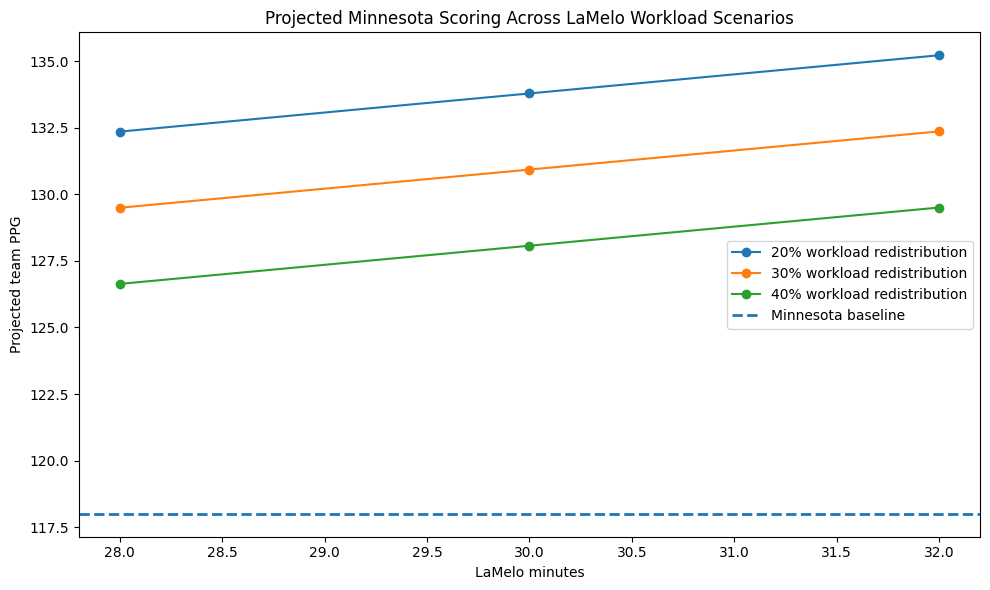

In [ ]:
plt.figure(figsize=(10, 6))

for redistribution_rate in sorted(
    workload_model["Redistribution"].unique()
):

    subset = workload_model[
        workload_model["Redistribution"] == redistribution_rate
    ]

    grouped = (
        subset
        .groupby("LaMelo_Minutes")["Projected_PPG"]
        .mean()
    )

    plt.plot(
        grouped.index,
        grouped.values,
        marker="o",
        label=f"{redistribution_rate:.0%} workload redistribution"
    )

plt.axhline(
    wolves_baseline["PPG"],
    linestyle="--",
    linewidth=2,
    label="Minnesota baseline"
)

plt.xlabel("LaMelo minutes")
plt.ylabel("Projected team PPG")
plt.title("Projected Minnesota Scoring Across LaMelo Workload Scenarios")
plt.legend()

plt.tight_layout()
plt.show()

**Visualizing net scoring impact**

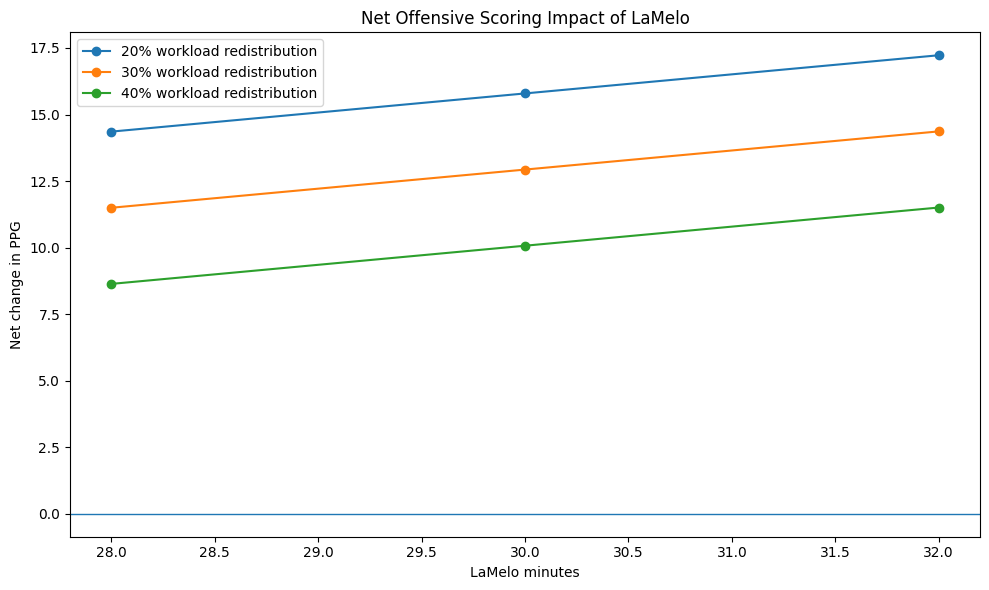

In [ ]:
plt.figure(figsize=(10, 6))

for redistribution_rate in sorted(
    workload_model["Redistribution"].unique()
):

    subset = workload_model[
        workload_model["Redistribution"] == redistribution_rate
    ]

    grouped = (
        subset
        .groupby("LaMelo_Minutes")["Net_PPG"]
        .mean()
    )

    plt.plot(
        grouped.index,
        grouped.values,
        marker="o",
        label=f"{redistribution_rate:.0%} workload redistribution"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("LaMelo minutes")
plt.ylabel("Net change in PPG")
plt.title("Net Offensive Scoring Impact of LaMelo")
plt.legend()

plt.tight_layout()
plt.show()

**Visualizing the creator structure**

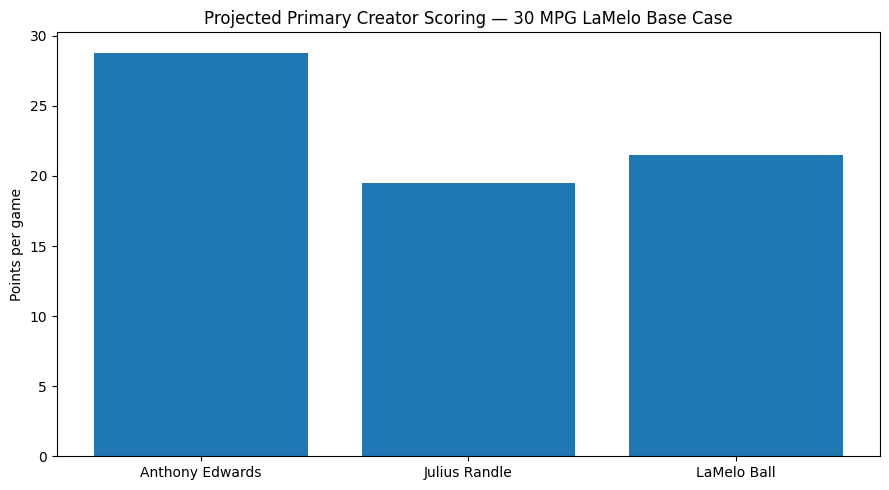

In [ ]:
base = workload_model[
    (workload_model["LaMelo_Minutes"] == 30) &
    (workload_model["Redistribution"] == 0.30) &
    (workload_model["Secondary_Share"] == 0.75)
].iloc[0]

creator_values = [
    edwards_baseline["PPG"],
    base["Projected_Randle_PPG"],
    base["Projected_Lamelo_PPG"]
]

creator_names = [
    "Anthony Edwards",
    "Julius Randle",
    "LaMelo Ball"
]

plt.figure(figsize=(9, 5))

plt.bar(
    creator_names,
    creator_values
)

plt.ylabel("Points per game")
plt.title("Projected Primary Creator Scoring — 30 MPG LaMelo Base Case")

plt.tight_layout()
plt.show()

**Model diagnostic summary**

In [ ]:
diagnostic = pd.DataFrame({
    "Metric": [
        "Minnesota baseline PPG",
        "Minnesota baseline ORTG",
        "Edwards PPG",
        "Randle PPG",
        "Secondary perimeter PPG",
        "LaMelo actual PPG",
        "LaMelo actual APG",
        "LaMelo actual 3PA",
        "LaMelo OFF EPM",
        "LaMelo EPM"
    ],
    "Value": [
        wolves_baseline["PPG"],
        wolves_baseline["ORTG"],
        edwards_baseline["PPG"],
        randle_baseline["PPG"],
        secondary_totals["PPG"],
        lamelo_actual["PPG"],
        lamelo_actual["APG"],
        lamelo_actual["3PA"],
        lamelo_epm["OFF_EPM"],
        lamelo_epm["EPM"]
    ]
})

diagnostic.round(2)

,Metric,Value
0,Minnesota baseline PPG,118.00
1,Minnesota baseline ORTG,114.90
2,Edwards PPG,28.80
3,Randle PPG,21.10
4,Secondary perimeter PPG,31.11
5,LaMelo actual PPG,20.07
6,LaMelo actual APG,7.14
7,LaMelo actual 3PA,10.28
8,LaMelo OFF EPM,5.90
9,LaMelo EPM,5.10


**Measuring LaMelo's scoring efficiency**

In [ ]:
lamelo_efficiency = pd.Series({
    "PPG": lamelo_actual["PPG"],
    "FGA": lamelo_actual["FGA"],
    "FTA": lamelo_actual["FTA"],
    "TS%": (
        lamelo_actual["PPG"]
        / (
            2 * (
                lamelo_actual["FGA"]
                + 0.44 * lamelo_actual["FTA"]
            )
        )
    ),
    "Points_per_FGA": (
        lamelo_actual["PPG"]
        / lamelo_actual["FGA"]
    )
})

lamelo_efficiency.round(3)

,0
PPG,20.069
FGA,17.278
FTA,2.486
TS%,0.546
Points_per_FGA,1.162


**Measuring Randle's scoring efficiency**

In [ ]:
randle_efficiency = pd.Series({
    "PPG": randle_baseline["PPG"],
    "FGA": randle_baseline["FGA"],
    "FTA": randle_baseline["FTA"],
    "TS%": (
        randle_baseline["PPG"]
        / (
            2 * (
                randle_baseline["FGA"]
                + 0.44 * randle_baseline["FTA"]
            )
        )
    ),
    "Points_per_FGA": (
        randle_baseline["PPG"]
        / randle_baseline["FGA"]
    )
})

randle_efficiency.round(3)

,0
PPG,21.101
FGA,15.278
FTA,6.278
TS%,0.585
Points_per_FGA,1.381


**Measuring the secondary perimeter group's scoring efficiency**

In [ ]:
secondary_efficiency = pd.Series({
    "PPG": secondary_totals["PPG"],
    "FGA": secondary_totals["FGA"],
    "FTA": secondary_totals["FTA"],
    "TS%": (
        secondary_totals["PPG"]
        / (
            2 * (
                secondary_totals["FGA"]
                + 0.44 * secondary_totals["FTA"]
            )
        )
    ),
    "Points_per_FGA": (
        secondary_totals["PPG"]
        / secondary_totals["FGA"]
    )
})

secondary_efficiency.round(3)

,0
PPG,31.107
FGA,25.039
FTA,3.873
TS%,0.582
Points_per_FGA,1.242


**Comparing offensive efficiency**

In [ ]:
efficiency_comparison = pd.DataFrame({
    "Group": [
        "LaMelo Ball",
        "Julius Randle",
        "Secondary perimeter"
    ],
    "PPG": [
        lamelo_efficiency["PPG"],
        randle_efficiency["PPG"],
        secondary_efficiency["PPG"]
    ],
    "FGA": [
        lamelo_efficiency["FGA"],
        randle_efficiency["FGA"],
        secondary_efficiency["FGA"]
    ],
    "FTA": [
        lamelo_efficiency["FTA"],
        randle_efficiency["FTA"],
        secondary_efficiency["FTA"]
    ],
    "TS%": [
        lamelo_efficiency["TS%"],
        randle_efficiency["TS%"],
        secondary_efficiency["TS%"]
    ],
    "Points_per_FGA": [
        lamelo_efficiency["Points_per_FGA"],
        randle_efficiency["Points_per_FGA"],
        secondary_efficiency["Points_per_FGA"]
    ]
})

efficiency_comparison.round(3)

,Group,PPG,FGA,FTA,TS%,Points_per_FGA
0,LaMelo Ball,20.069,17.278,2.486,0.546,1.162
1,Julius Randle,21.101,15.278,6.278,0.585,1.381
2,Secondary perimeter,31.107,25.039,3.873,0.582,1.242


**Measuring LaMelo's efficiency advantage or disadvantage**

In [ ]:
lamelo_vs_randle_ts = (
    lamelo_efficiency["TS%"]
    - randle_efficiency["TS%"]
)

lamelo_vs_secondary_ts = (
    lamelo_efficiency["TS%"]
    - secondary_efficiency["TS%"]
)

efficiency_gaps = pd.Series({
    "LaMelo_vs_Randle_TS": lamelo_vs_randle_ts,
    "LaMelo_vs_Secondary_TS": lamelo_vs_secondary_ts
})

efficiency_gaps.round(3)

,0
LaMelo_vs_Randle_TS,-0.039
LaMelo_vs_Secondary_TS,-0.035


**Measuring the shot profile of the three creator groups**

In [ ]:
shot_profile = pd.DataFrame({
    "Group": [
        "Anthony Edwards",
        "Julius Randle",
        "LaMelo Ball"
    ],
    "FGA": [
        edwards_baseline["FGA"],
        randle_baseline["FGA"],
        lamelo_actual["FGA"]
    ],
    "3PA": [
        edwards_baseline["3PA"],
        randle_baseline["3PA"],
        lamelo_actual["3PA"]
    ],
    "FTA": [
        edwards_baseline["FTA"],
        randle_baseline["FTA"],
        lamelo_actual["FTA"]
    ]
})

shot_profile["3PA_Rate"] = (
    shot_profile["3PA"]
    / shot_profile["FGA"]
)

shot_profile["FTA_Rate"] = (
    shot_profile["FTA"]
    / shot_profile["FGA"]
)

shot_profile.round(3)

,Group,FGA,3PA,FTA,3PA_Rate,FTA_Rate
0,Anthony Edwards,20.180,8.426,7.164,0.418,0.355
1,Julius Randle,15.278,4.380,6.278,0.287,0.411
2,LaMelo Ball,17.278,10.278,2.486,0.595,0.144


**Measuring the secondary perimeter shot profile**

In [ ]:
secondary_shot_profile = pd.Series({
    "FGA": secondary_totals["FGA"],
    "3PA": secondary_totals["3PA"],
    "FTA": secondary_totals["FTA"],
    "3PA_Rate": (
        secondary_totals["3PA"]
        / secondary_totals["FGA"]
    ),
    "FTA_Rate": (
        secondary_totals["FTA"]
        / secondary_totals["FGA"]
    )
})

secondary_shot_profile.round(3)

,0
FGA,25.039
3PA,14.553
FTA,3.873
3PA_Rate,0.581
FTA_Rate,0.155


**Projecting shot redistribution**

In [ ]:
base_case = workload_model[
    (workload_model["LaMelo_Minutes"] == 30) &
    (workload_model["Redistribution"] == 0.30) &
    (workload_model["Secondary_Share"] == 0.75)
].iloc[0]

base_shot_projection = pd.Series({
    "Baseline_FGA": wolves_baseline["FGA"],
    "Baseline_3PA": wolves_baseline["3PA"],
    "Baseline_FTA": wolves_baseline["FTA"],

    "LaMelo_FGA": base_case["LaMelo_FGA"],
    "LaMelo_3PA": base_case["LaMelo_3PA"],
    "LaMelo_FTA": base_case["LaMelo_FTA"],

    "Displaced_FGA": base_case["Displaced_FGA"],
    "Displaced_3PA": base_case["Displaced_3PA"],
    "Displaced_FTA": base_case["Displaced_FTA"]
})

base_shot_projection.round(2)

,0
Baseline_FGA,88.54
Baseline_3PA,37.18
Baseline_FTA,25.27
LaMelo_FGA,18.52
LaMelo_3PA,11.02
LaMelo_FTA,2.67
Displaced_FGA,6.78
Displaced_3PA,3.60
Displaced_FTA,1.34


**Projected team shot volume**

In [ ]:
projected_shot_volume = pd.Series({
    "Projected_FGA": (
        base_shot_projection["Baseline_FGA"]
        + base_shot_projection["LaMelo_FGA"]
        - base_shot_projection["Displaced_FGA"]
    ),

    "Projected_3PA": (
        base_shot_projection["Baseline_3PA"]
        + base_shot_projection["LaMelo_3PA"]
        - base_shot_projection["Displaced_3PA"]
    ),

    "Projected_FTA": (
        base_shot_projection["Baseline_FTA"]
        + base_shot_projection["LaMelo_FTA"]
        - base_shot_projection["Displaced_FTA"]
    )
})

projected_shot_volume["Projected_3PA_Rate"] = (
    projected_shot_volume["Projected_3PA"]
    / projected_shot_volume["Projected_FGA"]
)

projected_shot_volume.round(2)

,0
Projected_FGA,100.28
Projected_3PA,44.60
Projected_FTA,26.59
Projected_3PA_Rate,0.44


**Measuring LaMelo's direct creation versus scoring**

In [ ]:
lamelo_creation_summary = pd.Series({
    "PPG": lamelo_actual["PPG"],
    "APG": lamelo_actual["APG"],
    "Potential_AST": lamelo_tracking["Potential_AST"],
    "Drives": lamelo_tracking["Drives"],
    "Drive_PTS": lamelo_tracking["Drive_PTS"],
    "Pullup_3PA": lamelo_tracking["Pullup_3PA"],
    "AST_Points_Created": lamelo_tracking["AST_Points_Created"],
    "3PA": lamelo_actual["3PA"],
    "TOV": lamelo_actual["TOV"]
})

lamelo_creation_summary.round(2)

,0
PPG,20.07
APG,7.14
Potential_AST,11.60
Drives,13.40
Drive_PTS,6.40
Pullup_3PA,5.60
AST_Points_Created,18.60
3PA,10.28
TOV,2.81


**Measuring Edwards' baseline offensive burden**

In [ ]:
edwards_creation = pd.Series({
    "PPG": edwards_baseline["PPG"],
    "APG": edwards_baseline["APG"],
    "FGA": edwards_baseline["FGA"],
    "3PA": edwards_baseline["3PA"],
    "FTA": edwards_baseline["FTA"],
    "TOV": edwards_baseline["TOV"]
})

edwards_creation.round(2)

,0
PPG,28.80
APG,3.70
FGA,20.18
3PA,8.43
FTA,7.16
TOV,2.85


**Measuring Randle's baseline offensive burden**

In [ ]:
randle_creation = pd.Series({
    "PPG": randle_baseline["PPG"],
    "APG": randle_baseline["APG"],
    "FGA": randle_baseline["FGA"],
    "3PA": randle_baseline["3PA"],
    "FTA": randle_baseline["FTA"],
    "TOV": randle_baseline["TOV"]
})

randle_creation.round(2)

,0
PPG,21.10
APG,5.04
FGA,15.28
3PA,4.38
FTA,6.28
TOV,2.75


**Comparing the three main creators**

In [ ]:
creator_comparison = pd.DataFrame({
    "Player": [
        "Anthony Edwards",
        "Julius Randle",
        "LaMelo Ball"
    ],
    "PPG": [
        edwards_creation["PPG"],
        randle_creation["PPG"],
        lamelo_creation_summary["PPG"]
    ],
    "APG": [
        edwards_creation["APG"],
        randle_creation["APG"],
        lamelo_creation_summary["APG"]
    ],
    "FGA": [
        edwards_creation["FGA"],
        randle_creation["FGA"],
        lamelo_actual["FGA"]
    ],
    "3PA": [
        edwards_creation["3PA"],
        randle_creation["3PA"],
        lamelo_actual["3PA"]
    ],
    "FTA": [
        edwards_creation["FTA"],
        randle_creation["FTA"],
        lamelo_actual["FTA"]
    ],
    "TOV": [
        edwards_creation["TOV"],
        randle_creation["TOV"],
        lamelo_actual["TOV"]
    ]
})

creator_comparison.round(2)

,Player,PPG,APG,FGA,3PA,FTA,TOV
0,Anthony Edwards,28.80,3.70,20.18,8.43,7.16,2.85
1,Julius Randle,21.10,5.04,15.28,4.38,6.28,2.75
2,LaMelo Ball,20.07,7.14,17.28,10.28,2.49,2.81


**Visualizing the three-creator scoring structure**

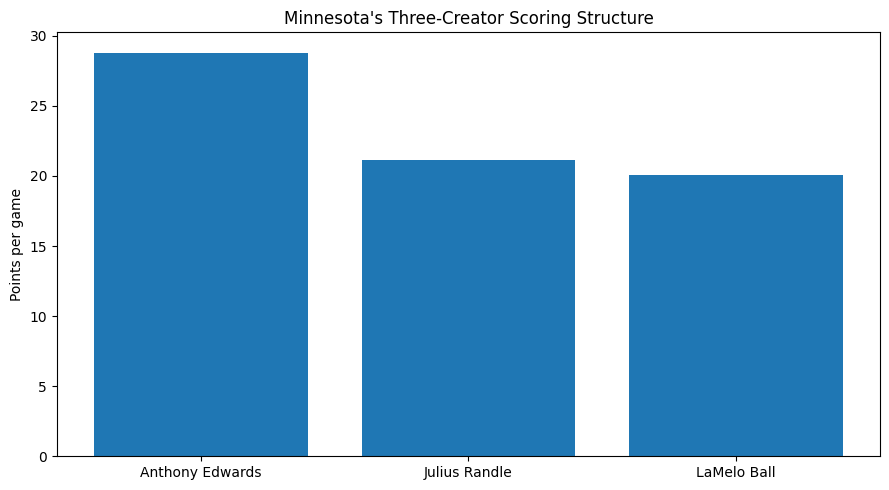

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    creator_comparison["Player"],
    creator_comparison["PPG"]
)

plt.ylabel("Points per game")
plt.title("Minnesota's Three-Creator Scoring Structure")

plt.tight_layout()
plt.show()

**Visualizing creator shot volume**

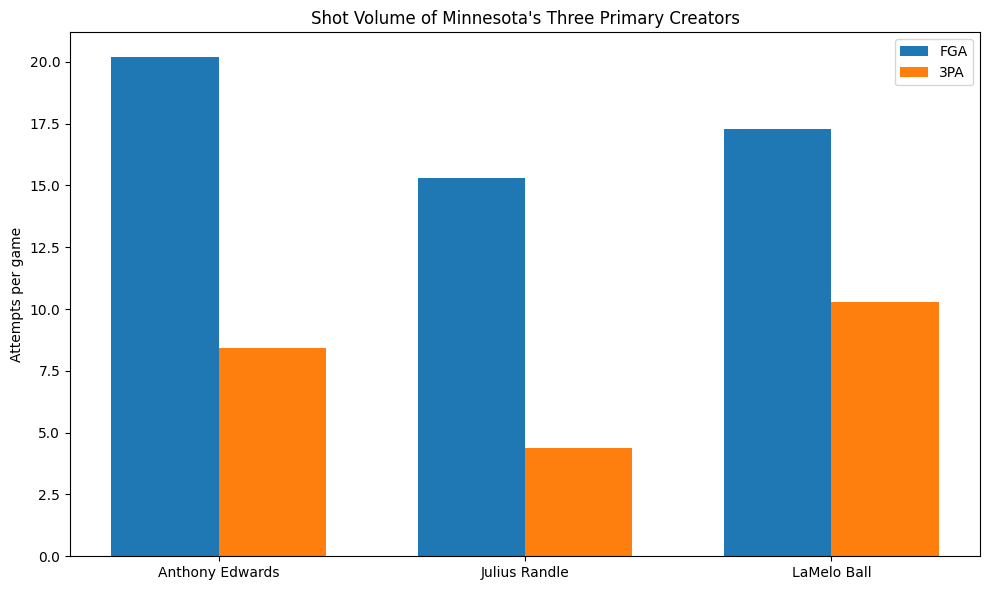

In [ ]:
x = np.arange(len(creator_comparison))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    creator_comparison["FGA"],
    width,
    label="FGA"
)

plt.bar(
    x + width / 2,
    creator_comparison["3PA"],
    width,
    label="3PA"
)

plt.xticks(x, creator_comparison["Player"])
plt.ylabel("Attempts per game")
plt.title("Shot Volume of Minnesota's Three Primary Creators")
plt.legend()

plt.tight_layout()
plt.show()

**Edwards and Randle workload sensitivity**

In [ ]:
sensitivity_levels = [0.00, 0.05, 0.10]

sensitivity_rows = []

base_case = workload_model[
    (workload_model["LaMelo_Minutes"] == 30) &
    (workload_model["Redistribution"] == 0.30) &
    (workload_model["Secondary_Share"] == 0.75)
].iloc[0]

for edwards_reduction in sensitivity_levels:
    for randle_reduction in sensitivity_levels:

        edwards_ppg = (
            edwards_baseline["PPG"]
            * (1 - edwards_reduction)
        )

        randle_ppg = (
            randle_baseline["PPG"]
            * (1 - randle_reduction)
        )

        projected_ppg = (
            wolves_baseline["PPG"]
            - (
                edwards_baseline["PPG"]
                * edwards_reduction
            )
            - (
                randle_baseline["PPG"]
                * randle_reduction
            )
            + base_case["Net_PPG"]
        )

        sensitivity_rows.append({
            "Edwards_Reduction": edwards_reduction,
            "Randle_Reduction": randle_reduction,
            "Edwards_PPG": edwards_ppg,
            "Randle_PPG": randle_ppg,
            "LaMelo_PPG": base_case["LaMelo_PPG"],
            "Projected_Team_PPG": projected_ppg
        })

sensitivity = pd.DataFrame(sensitivity_rows)

sensitivity.round(2)

,Edwards_Reduction,Randle_Reduction,Edwards_PPG,Randle_PPG,LaMelo_PPG,Projected_Team_PPG
0,0.00,0.00,28.80,21.10,21.51,130.93
1,0.00,0.05,28.80,20.05,21.51,129.88
2,0.00,0.10,28.80,18.99,21.51,128.82
3,0.05,0.00,27.36,21.10,21.51,129.49
4,0.05,0.05,27.36,20.05,21.51,128.44
5,0.05,0.10,27.36,18.99,21.51,127.38
6,0.10,0.00,25.92,21.10,21.51,128.05
7,0.10,0.05,25.92,20.05,21.51,127.00
8,0.10,0.10,25.92,18.99,21.51,125.94


**Measuring the creator workload shift**

In [ ]:
base_creator = pd.Series({
    "Anthony Edwards": edwards_baseline["PPG"],
    "Julius Randle": randle_baseline["PPG"],
    "LaMelo Ball": 0
})

post_creator = pd.Series({
    "Anthony Edwards": base_case["Projected_Edwards_PPG"],
    "Julius Randle": base_case["Projected_Randle_PPG"],
    "LaMelo Ball": base_case["Projected_Lamelo_PPG"]
})

creator_shift = pd.DataFrame({
    "Before": base_creator,
    "After": post_creator
})

creator_shift["Change"] = (
    creator_shift["After"]
    - creator_shift["Before"]
)

creator_shift.round(2)

,Before,After,Change
Anthony Edwards,28.8,28.80,0.00
Julius Randle,21.1,19.52,-1.58
LaMelo Ball,0.0,21.51,21.51


**Testing the efficiency-adjusted scoring effect**

In [ ]:
base_fga_displaced = base_case["Displaced_FGA"]
base_lamelo_fga = base_case["LaMelo_FGA"]

displaced_points_per_fga = (
    base_case["Displaced_PPG"]
    / base_fga_displaced
)

lamelo_points_per_fga = (
    base_case["LaMelo_PPG"]
    / base_lamelo_fga
)

efficiency_adjustment = pd.Series({
    "Displaced_points_per_FGA": displaced_points_per_fga,
    "LaMelo_points_per_FGA": lamelo_points_per_fga,
    "Efficiency_difference": (
        lamelo_points_per_fga
        - displaced_points_per_fga
    ),
    "LaMelo_FGA_added": base_lamelo_fga,
    "Displaced_FGA": base_fga_displaced
})

efficiency_adjustment.round(3)

,0
Displaced_points_per_FGA,1.266
LaMelo_points_per_FGA,1.162
Efficiency_difference,-0.104
LaMelo_FGA_added,18.521
Displaced_FGA,6.780


**Building the efficiency-adjusted base case**

In [ ]:
efficiency_adjusted_ppg = (
    wolves_baseline["PPG"]
    + (
        base_case["LaMelo_FGA"]
        * lamelo_points_per_fga
    )
    - (
        base_case["Displaced_FGA"]
        * displaced_points_per_fga
    )
)

efficiency_adjusted_change = (
    efficiency_adjusted_ppg
    - wolves_baseline["PPG"]
)

efficiency_adjusted = pd.Series({
    "Baseline_PPG": wolves_baseline["PPG"],
    "LaMelo_added_points": (
        base_case["LaMelo_FGA"]
        * lamelo_points_per_fga
    ),
    "Displaced_points": (
        base_case["Displaced_FGA"]
        * displaced_points_per_fga
    ),
    "Projected_PPG": efficiency_adjusted_ppg,
    "Net_PPG_change": efficiency_adjusted_change
})

efficiency_adjusted.round(2)

,0
Baseline_PPG,118.00
LaMelo_added_points,21.51
Displaced_points,8.58
Projected_PPG,130.93
Net_PPG_change,12.93


**Adding turnover impact**

In [ ]:
turnover_comparison = pd.Series({
    "LaMelo_TOV": base_case["LaMelo_TOV"],
    "Displaced_TOV": base_case["Displaced_TOV"],
    "Net_TOV_Change": (
        base_case["LaMelo_TOV"]
        - base_case["Displaced_TOV"]
    )
})

turnover_comparison.round(2)

,0
LaMelo_TOV,3.01
Displaced_TOV,1.00
Net_TOV_Change,2.01


**Projecting the three-point redistribution**

In [ ]:
three_point_impact = pd.Series({
    "Baseline_3PA": wolves_baseline["3PA"],
    "LaMelo_3PA": base_case["LaMelo_3PA"],
    "Displaced_3PA": base_case["Displaced_3PA"],
    "Projected_3PA": (
        wolves_baseline["3PA"]
        + base_case["LaMelo_3PA"]
        - base_case["Displaced_3PA"]
    )
})

three_point_impact["Change_3PA"] = (
    three_point_impact["Projected_3PA"]
    - three_point_impact["Baseline_3PA"]
)

three_point_impact.round(2)

,0
Baseline_3PA,37.18
LaMelo_3PA,11.02
Displaced_3PA,3.60
Projected_3PA,44.60
Change_3PA,7.41


**Quantifying LaMelo's creation mechanisms**

In [ ]:
creation_metrics = pd.DataFrame({
    "Metric": [
        "Points per game",
        "Assists per game",
        "Potential assists",
        "Drives",
        "Drive points",
        "Pull-up 3PA",
        "Pull-up 3P%",
        "Passes made",
        "AST points created",
        "Turnovers"
    ],
    "LaMelo": [
        lamelo_actual["PPG"],
        lamelo_actual["APG"],
        lamelo_tracking["Potential_AST"],
        lamelo_tracking["Drives"],
        lamelo_tracking["Drive_PTS"],
        lamelo_tracking["Pullup_3PA"],
        lamelo_tracking["Pullup_3P%"],
        lamelo_tracking["Passes_Made"],
        lamelo_tracking["AST_Points_Created"],
        lamelo_actual["TOV"]
    ]
})

creation_metrics.round(2)

,Metric,LaMelo
0,Points per game,20.07
1,Assists per game,7.14
2,Potential assists,11.60
3,Drives,13.40
4,Drive points,6.40
5,Pull-up 3PA,5.60
6,Pull-up 3P%,36.80
7,Passes made,48.80
8,AST points created,18.60
9,Turnovers,2.81


**Measuring the change in offensive responsibility**

In [ ]:
baseline_creation = pd.Series({
    "Scoring": (
        edwards_baseline["PPG"]
        + randle_baseline["PPG"]
    ),
    "Assists": (
        edwards_baseline["APG"]
        + randle_baseline["APG"]
    ),
    "FGA": (
        edwards_baseline["FGA"]
        + randle_baseline["FGA"]
    ),
    "3PA": (
        edwards_baseline["3PA"]
        + randle_baseline["3PA"]
    )
})

projected_creation = pd.Series({
    "Scoring": (
        edwards_baseline["PPG"]
        + base_case["Projected_Randle_PPG"]
        + base_case["LaMelo_PPG"]
    ),
    "Assists": (
        edwards_baseline["APG"]
        + randle_baseline["APG"]
        + base_case["LaMelo_APG"]
    ),
    "FGA": (
        edwards_baseline["FGA"]
        + randle_baseline["FGA"]
        + base_case["LaMelo_FGA"]
    ),
    "3PA": (
        edwards_baseline["3PA"]
        + randle_baseline["3PA"]
        + base_case["LaMelo_3PA"]
    )
})

creation_shift = pd.DataFrame({
    "Baseline_Two_Creators": baseline_creation,
    "Projected_Three_Creators": projected_creation
})

creation_shift["Change"] = (
    creation_shift["Projected_Three_Creators"]
    - creation_shift["Baseline_Two_Creators"]
)

creation_shift.round(2)

,Baseline_Two_Creators,Projected_Three_Creators,Change
Scoring,49.90,69.84,19.93
Assists,8.74,16.40,7.65
FGA,35.46,53.98,18.52
3PA,12.81,23.82,11.02


**Running the Monte Carlo simulation**

In [ ]:
np.random.seed(42)

n_simulations = 10000

sim_minutes = np.random.uniform(28, 32, n_simulations)
sim_redistribution = np.random.uniform(0.20, 0.40, n_simulations)
sim_secondary_share = np.random.uniform(0.65, 0.85, n_simulations)

base_ppg_rate = lamelo_actual["PPG"] / lamelo_actual["MPG"]
base_apg_rate = lamelo_actual["APG"] / lamelo_actual["MPG"]
base_3pa_rate = lamelo_actual["3PA"] / lamelo_actual["MPG"]

sim_ppg_rate = base_ppg_rate * np.random.normal(
    1.00, 0.05, n_simulations
)

sim_apg_rate = base_apg_rate * np.random.normal(
    1.00, 0.05, n_simulations
)

sim_3pa_rate = base_3pa_rate * np.random.normal(
    1.00, 0.05, n_simulations
)

sim_lamelo_ppg = sim_minutes * sim_ppg_rate
sim_lamelo_apg = sim_minutes * sim_apg_rate
sim_lamelo_3pa = sim_minutes * sim_3pa_rate

sim_randle_share = 1 - sim_secondary_share

sim_displaced_ppg = (
    (
        randle_baseline["PPG"] * sim_randle_share
    )
    +
    (
        secondary_totals["PPG"] * sim_secondary_share
    )
) * sim_redistribution

sim_displaced_apg = (
    (
        randle_baseline["APG"] * sim_randle_share
    )
    +
    (
        secondary_totals["APG"] * sim_secondary_share
    )
) * sim_redistribution

sim_displaced_3pa = (
    (
        randle_baseline["3PA"] * sim_randle_share
    )
    +
    (
        secondary_totals["3PA"] * sim_secondary_share
    )
) * sim_redistribution

sim_net_ppg = (
    sim_lamelo_ppg
    - sim_displaced_ppg
)

sim_net_apg = (
    sim_lamelo_apg
    - sim_displaced_apg
)

sim_net_3pa = (
    sim_lamelo_3pa
    - sim_displaced_3pa
)

sim_projected_ppg = (
    wolves_baseline["PPG"]
    + sim_net_ppg
)

monte_carlo = pd.DataFrame({
    "Minutes": sim_minutes,
    "Redistribution": sim_redistribution,
    "Secondary_Share": sim_secondary_share,
    "LaMelo_PPG": sim_lamelo_ppg,
    "LaMelo_APG": sim_lamelo_apg,
    "LaMelo_3PA": sim_lamelo_3pa,
    "Displaced_PPG": sim_displaced_ppg,
    "Displaced_APG": sim_displaced_apg,
    "Displaced_3PA": sim_displaced_3pa,
    "Net_PPG": sim_net_ppg,
    "Net_APG": sim_net_apg,
    "Net_3PA": sim_net_3pa,
    "Projected_PPG": sim_projected_ppg
})

monte_carlo.describe().round(2)

,Minutes,Redistribution,Secondary_Share,LaMelo_PPG,LaMelo_APG,LaMelo_3PA,Displaced_PPG,Displaced_APG,Displaced_3PA,Net_PPG,Net_APG,Net_3PA,Projected_PPG
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,29.98,0.30,0.75,21.49,7.65,11.01,8.61,2.70,3.61,12.88,4.95,7.40,130.88
std,1.15,0.06,0.06,1.35,0.49,0.69,1.66,0.52,0.71,2.14,0.72,1.00,2.14
min,28.00,0.20,0.65,15.74,5.95,8.60,5.56,1.70,2.23,4.48,2.62,4.14,122.48
25%,28.99,0.25,0.70,20.56,7.31,10.53,7.17,2.25,3.01,11.31,4.44,6.69,129.31
50%,29.97,0.30,0.75,21.45,7.64,11.00,8.61,2.70,3.61,12.87,4.96,7.41,130.87
75%,30.96,0.35,0.80,22.41,7.98,11.48,10.04,3.14,4.21,14.43,5.46,8.10,132.43
max,32.00,0.40,0.85,27.01,9.50,13.87,11.80,3.78,5.18,20.29,7.36,10.97,138.29


**Monte Carlo summary**

In [ ]:
monte_carlo_summary = pd.DataFrame({
    "Metric": [
        "LaMelo PPG",
        "LaMelo APG",
        "LaMelo 3PA",
        "Net PPG change",
        "Net APG change",
        "Net 3PA change",
        "Projected Minnesota PPG"
    ],
    "5th_percentile": [
        monte_carlo["LaMelo_PPG"].quantile(0.05),
        monte_carlo["LaMelo_APG"].quantile(0.05),
        monte_carlo["LaMelo_3PA"].quantile(0.05),
        monte_carlo["Net_PPG"].quantile(0.05),
        monte_carlo["Net_APG"].quantile(0.05),
        monte_carlo["Net_3PA"].quantile(0.05),
        monte_carlo["Projected_PPG"].quantile(0.05)
    ],
    "Median": [
        monte_carlo["LaMelo_PPG"].median(),
        monte_carlo["LaMelo_APG"].median(),
        monte_carlo["LaMelo_3PA"].median(),
        monte_carlo["Net_PPG"].median(),
        monte_carlo["Net_APG"].median(),
        monte_carlo["Net_3PA"].median(),
        monte_carlo["Projected_PPG"].median()
    ],
    "95th_percentile": [
        monte_carlo["LaMelo_PPG"].quantile(0.95),
        monte_carlo["LaMelo_APG"].quantile(0.95),
        monte_carlo["LaMelo_3PA"].quantile(0.95),
        monte_carlo["Net_PPG"].quantile(0.95),
        monte_carlo["Net_APG"].quantile(0.95),
        monte_carlo["Net_3PA"].quantile(0.95),
        monte_carlo["Projected_PPG"].quantile(0.95)
    ]
})

monte_carlo_summary.round(2)

,Metric,5th_percentile,Median,95th_percentile
0,LaMelo PPG,19.31,21.45,23.75
1,LaMelo APG,6.86,7.64,8.47
2,LaMelo 3PA,9.88,11.00,12.16
3,Net PPG change,9.40,12.87,16.41
4,Net APG change,3.77,4.96,6.12
5,Net 3PA change,5.76,7.41,9.01
6,Projected Minnesota PPG,127.40,130.87,134.41


**Creating the efficiency-adjusted offensive scenarios**

In [ ]:
efficiency_scenarios = workload_model.copy()

lamelo_points_per_fga = (
    lamelo_actual["PPG"] / lamelo_actual["FGA"]
)

randle_points_per_fga = (
    randle_baseline["PPG"] / randle_baseline["FGA"]
)

secondary_points_per_fga = (
    secondary_totals["PPG"] / secondary_totals["FGA"]
)

efficiency_scenarios["Randle_FGA_Displaced"] = (
    randle_baseline["FGA"]
    * efficiency_scenarios["Redistribution"]
    * (1 - efficiency_scenarios["Secondary_Share"])
)

efficiency_scenarios["Secondary_FGA_Displaced"] = (
    secondary_totals["FGA"]
    * efficiency_scenarios["Redistribution"]
    * efficiency_scenarios["Secondary_Share"]
)

efficiency_scenarios["LaMelo_Estimated_Points"] = (
    efficiency_scenarios["LaMelo_FGA"]
    * lamelo_points_per_fga
)

efficiency_scenarios["Randle_Displaced_Points"] = (
    efficiency_scenarios["Randle_FGA_Displaced"]
    * randle_points_per_fga
)

efficiency_scenarios["Secondary_Displaced_Points"] = (
    efficiency_scenarios["Secondary_FGA_Displaced"]
    * secondary_points_per_fga
)

efficiency_scenarios["Efficiency_Adjusted_Net_Points"] = (
    efficiency_scenarios["LaMelo_Estimated_Points"]
    - efficiency_scenarios["Randle_Displaced_Points"]
    - efficiency_scenarios["Secondary_Displaced_Points"]
)

efficiency_scenarios[
    [
        "LaMelo_Minutes",
        "Redistribution",
        "Secondary_Share",
        "Efficiency_Adjusted_Net_Points"
    ]
].round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Efficiency_Adjusted_Net_Points
0,28.0,0.2,0.65,14.56
1,28.0,0.2,0.75,14.36
2,28.0,0.2,0.85,14.16
3,28.0,0.3,0.65,11.80
4,28.0,0.3,0.75,11.50
5,28.0,0.3,0.85,11.20
6,28.0,0.4,0.65,9.04
7,28.0,0.4,0.75,8.64
8,28.0,0.4,0.85,8.24
9,30.0,0.2,0.65,15.99


**Building the final base-case comparison**

In [ ]:
base_efficiency_case = efficiency_scenarios[
    (efficiency_scenarios["LaMelo_Minutes"] == 30) &
    (efficiency_scenarios["Redistribution"] == 0.30) &
    (efficiency_scenarios["Secondary_Share"] == 0.75)
].iloc[0]

base_comparison = pd.Series({
    "Minnesota baseline PPG": wolves_baseline["PPG"],
    "Workload model PPG": base_case["Projected_PPG"],
    "LaMelo PPG": base_case["LaMelo_PPG"],
    "Displaced PPG": base_case["Displaced_PPG"],
    "Efficiency-adjusted net points": base_efficiency_case["Efficiency_Adjusted_Net_Points"]
})

base_comparison.round(2)

,0
Minnesota baseline PPG,118.00
Workload model PPG,130.93
LaMelo PPG,21.51
Displaced PPG,8.58
Efficiency-adjusted net points,12.93


**Projected scoring across workload assumptions**

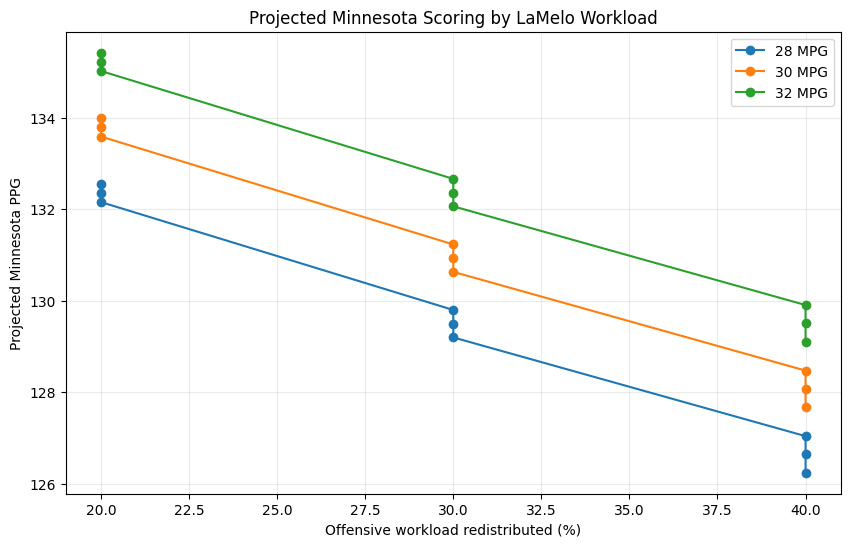

In [ ]:
plt.figure(figsize=(10, 6))

for minutes in [28, 30, 32]:
    subset = workload_model[
        workload_model["LaMelo_Minutes"] == minutes
    ]

    plt.plot(
        subset["Redistribution"] * 100,
        subset["Projected_PPG"],
        marker="o",
        label=f"{minutes} MPG"
    )

plt.xlabel("Offensive workload redistributed (%)")
plt.ylabel("Projected Minnesota PPG")
plt.title("Projected Minnesota Scoring by LaMelo Workload")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Net offensive scoring impact**

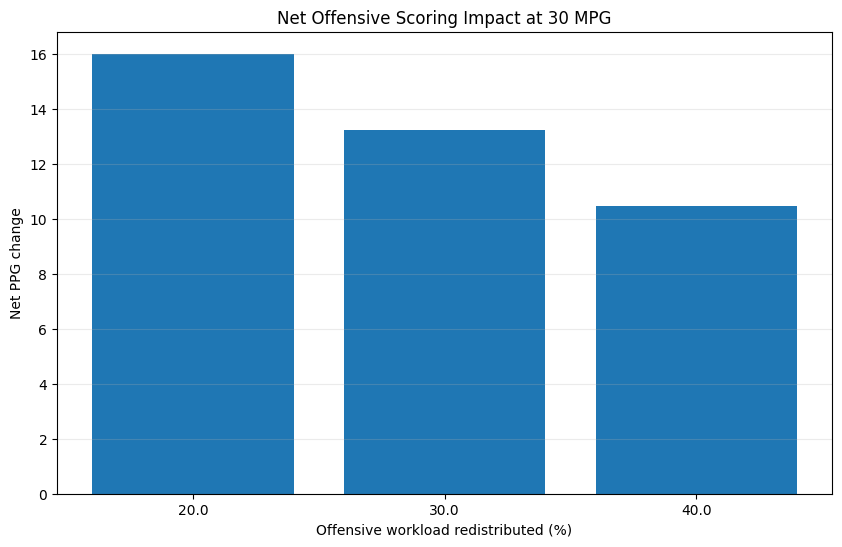

In [ ]:
plt.figure(figsize=(10, 6))

base_minutes = workload_model[
    workload_model["LaMelo_Minutes"] == 30
].copy()

plt.bar(
    (base_minutes["Redistribution"] * 100).astype(str),
    base_minutes["Net_PPG"]
)

plt.xlabel("Offensive workload redistributed (%)")
plt.ylabel("Net PPG change")
plt.title("Net Offensive Scoring Impact at 30 MPG")
plt.grid(axis="y", alpha=0.25)
plt.show()

**Creator scoring structure**

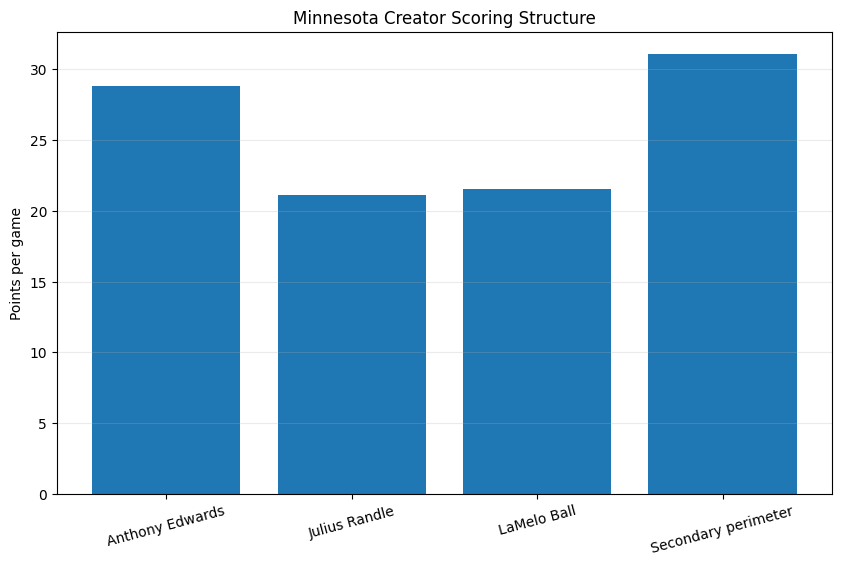

In [ ]:
creator_structure = pd.DataFrame({
    "Creator": [
        "Anthony Edwards",
        "Julius Randle",
        "LaMelo Ball",
        "Secondary perimeter"
    ],
    "Baseline_PPG": [
        edwards_baseline["PPG"],
        randle_baseline["PPG"],
        base_case["LaMelo_PPG"],
        secondary_totals["PPG"]
    ]
})

plt.figure(figsize=(10, 6))

plt.bar(
    creator_structure["Creator"],
    creator_structure["Baseline_PPG"]
)

plt.ylabel("Points per game")
plt.title("Minnesota Creator Scoring Structure")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()

**Projected three-point volume**

In [ ]:
efficiency_scenarios = workload_model.copy()

lamelo_points_per_fga = (
    lamelo_actual["PPG"] / lamelo_actual["FGA"]
)

randle_points_per_fga = (
    randle_baseline["PPG"] / randle_baseline["FGA"]
)

secondary_points_per_fga = (
    secondary_totals["PPG"] / secondary_totals["FGA"]
)

efficiency_scenarios["Randle_FGA_Displaced"] = (
    randle_baseline["FGA"]
    * efficiency_scenarios["Redistribution"]
    * (1 - efficiency_scenarios["Secondary_Share"])
)

efficiency_scenarios["Secondary_FGA_Displaced"] = (
    secondary_totals["FGA"]
    * efficiency_scenarios["Redistribution"]
    * efficiency_scenarios["Secondary_Share"]
)

efficiency_scenarios["LaMelo_Estimated_Points"] = (
    efficiency_scenarios["LaMelo_FGA"]
    * lamelo_points_per_fga
)

efficiency_scenarios["Randle_Displaced_Points"] = (
    efficiency_scenarios["Randle_FGA_Displaced"]
    * randle_points_per_fga
)

efficiency_scenarios["Secondary_Displaced_Points"] = (
    efficiency_scenarios["Secondary_FGA_Displaced"]
    * secondary_points_per_fga
)

efficiency_scenarios["Efficiency_Adjusted_Net_Points"] = (
    efficiency_scenarios["LaMelo_Estimated_Points"]
    - efficiency_scenarios["Randle_Displaced_Points"]
    - efficiency_scenarios["Secondary_Displaced_Points"]
)

efficiency_scenarios[
    [
        "LaMelo_Minutes",
        "Redistribution",
        "Secondary_Share",
        "Efficiency_Adjusted_Net_Points"
    ]
].round(2)

,LaMelo_Minutes,Redistribution,Secondary_Share,Efficiency_Adjusted_Net_Points
0,28.0,0.2,0.65,14.56
1,28.0,0.2,0.75,14.36
2,28.0,0.2,0.85,14.16
3,28.0,0.3,0.65,11.80
4,28.0,0.3,0.75,11.50
5,28.0,0.3,0.85,11.20
6,28.0,0.4,0.65,9.04
7,28.0,0.4,0.75,8.64
8,28.0,0.4,0.85,8.24
9,30.0,0.2,0.65,15.99


**Final base-case diagnostic**

In [ ]:
base_efficiency_case = efficiency_scenarios[
    (efficiency_scenarios["LaMelo_Minutes"].astype(float) == 30) &
    (efficiency_scenarios["Redistribution"] == 0.30) &
    (efficiency_scenarios["Secondary_Share"] == 0.75)
].iloc[0]

base_diagnostic = pd.Series({
    "Minnesota baseline PPG": wolves_baseline["PPG"],
    "LaMelo projected PPG": base_case["LaMelo_PPG"],
    "Workload-model net PPG change": base_case["Net_PPG"],
    "Efficiency-adjusted net points": base_efficiency_case["Efficiency_Adjusted_Net_Points"],
    "LaMelo projected 3PA": base_case["LaMelo_3PA"],
    "Net team 3PA change": base_case["Net_3PA"],
    "LaMelo projected APG": base_case["LaMelo_APG"],
    "Net team APG change": base_case["Net_APG"]
})

base_diagnostic.round(2)

,0
Minnesota baseline PPG,118.00
LaMelo projected PPG,21.51
Workload-model net PPG change,12.93
Efficiency-adjusted net points,12.93
LaMelo projected 3PA,11.02
Net team 3PA change,7.41
LaMelo projected APG,7.65
Net team APG change,4.96


**Efficiency-adjusted scenario matrix**

In [ ]:
scenario_matrix = efficiency_scenarios.pivot_table(
    index="Redistribution",
    columns="LaMelo_Minutes",
    values="Efficiency_Adjusted_Net_Points"
)

scenario_matrix.index = [
    f"{int(x * 100)}%"
    for x in scenario_matrix.index
]

scenario_matrix.columns = [
    f"{int(float(x))} MPG"
    for x in scenario_matrix.columns
]

scenario_matrix.round(2)

,28 MPG,30 MPG,32 MPG
20%,14.36,15.79,17.23
30%,11.50,12.93,14.37
40%,8.64,10.07,11.51


**Monte Carlo projected scoring distribution**

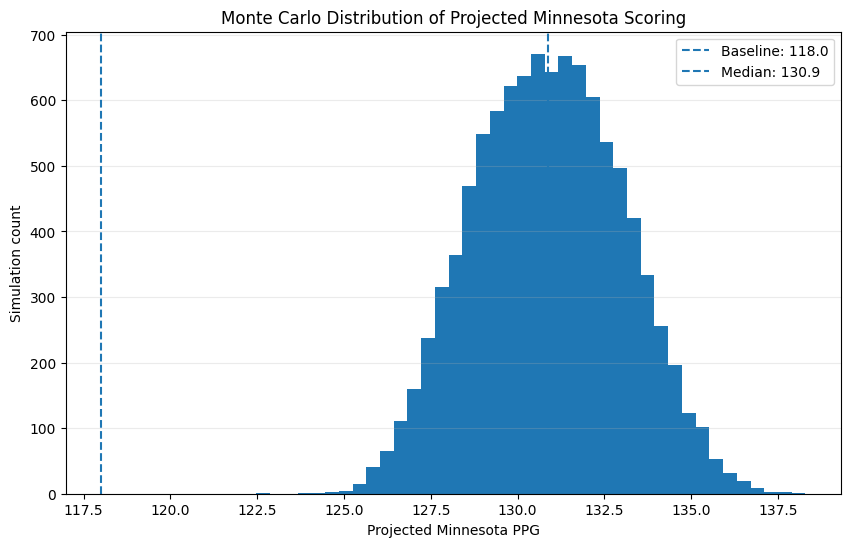

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    monte_carlo["Projected_PPG"],
    bins=40
)

plt.axvline(
    wolves_baseline["PPG"],
    linestyle="--",
    label=f"Baseline: {wolves_baseline['PPG']:.1f}"
)

plt.axvline(
    monte_carlo["Projected_PPG"].median(),
    linestyle="--",
    label=f"Median: {monte_carlo['Projected_PPG'].median():.1f}"
)

plt.xlabel("Projected Minnesota PPG")
plt.ylabel("Simulation count")
plt.title("Monte Carlo Distribution of Projected Minnesota Scoring")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

**Before vs after creator structure**

In [ ]:
base_redistribution = 0.30
base_secondary_share = 0.75
base_randle_share = 0.25

before_after_creators = pd.DataFrame({
    "Creator": [
        "Anthony Edwards",
        "Julius Randle",
        "LaMelo Ball",
        "Secondary perimeter"
    ],
    "Before": [
        edwards_baseline["PPG"],
        randle_baseline["PPG"],
        0,
        secondary_totals["PPG"]
    ],
    "After": [
        edwards_baseline["PPG"],
        randle_baseline["PPG"] * (1 - base_redistribution * base_randle_share),
        base_case["LaMelo_PPG"],
        secondary_totals["PPG"] * (1 - base_redistribution * base_secondary_share)
    ]
})

before_after_creators.round(2)

,Creator,Before,After
0,Anthony Edwards,28.80,28.80
1,Julius Randle,21.10,19.52
2,LaMelo Ball,0.00,21.51
3,Secondary perimeter,31.11,24.11


**Visualizing the before and after creator structure**

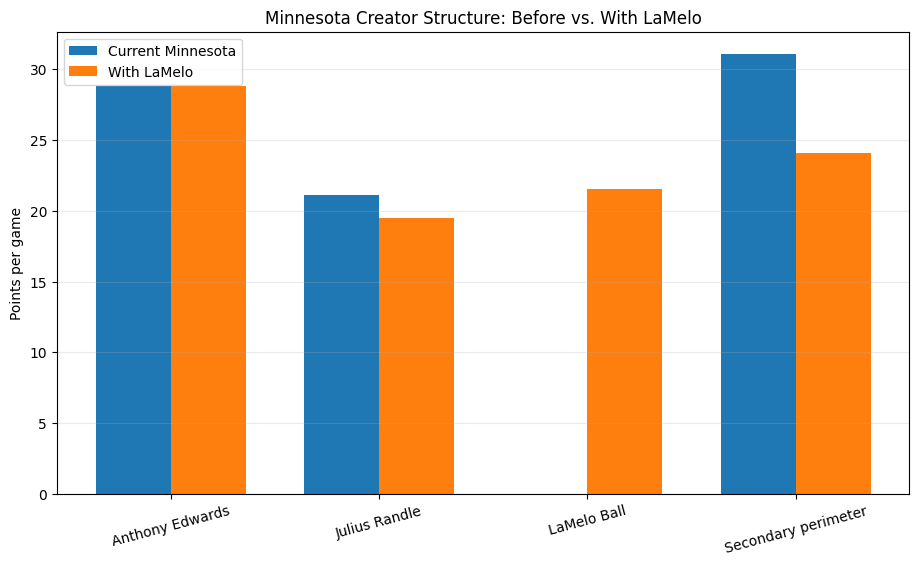

In [ ]:
x = np.arange(len(before_after_creators))
width = 0.36

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    before_after_creators["Before"],
    width,
    label="Current Minnesota"
)

plt.bar(
    x + width / 2,
    before_after_creators["After"],
    width,
    label="With LaMelo"
)

plt.xticks(
    x,
    before_after_creators["Creator"],
    rotation=15
)

plt.ylabel("Points per game")
plt.title("Minnesota Creator Structure: Before vs. With LaMelo")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()

**Creator scoring share before and after**

In [ ]:
creator_share = before_after_creators.copy()

creator_share["Before_Share"] = (
    creator_share["Before"] /
    creator_share["Before"].sum()
)

creator_share["After_Share"] = (
    creator_share["After"] /
    creator_share["After"].sum()
)

creator_share[[
    "Creator",
    "Before_Share",
    "After_Share"
]].round(3)

,Creator,Before_Share,After_Share
0,Anthony Edwards,0.356,0.307
1,Julius Randle,0.260,0.208
2,LaMelo Ball,0.000,0.229
3,Secondary perimeter,0.384,0.257


**Visualizing creator scoring concentration**

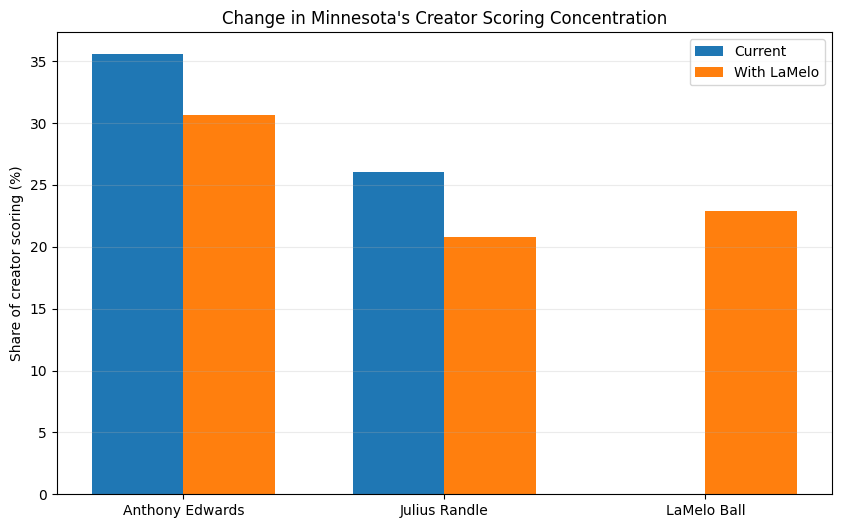

In [ ]:
creator_concentration = creator_share[
    creator_share["Creator"] != "Secondary perimeter"
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    creator_concentration["Creator"],
    creator_concentration["Before_Share"] * 100,
    width=0.35,
    label="Current"
)

plt.bar(
    np.arange(len(creator_concentration["Creator"])) + 0.35,
    creator_concentration["After_Share"] * 100,
    width=0.35,
    label="With LaMelo"
)

plt.xticks(
    np.arange(len(creator_concentration["Creator"])) + 0.175,
    creator_concentration["Creator"]
)

plt.ylabel("Share of creator scoring (%)")
plt.title("Change in Minnesota's Creator Scoring Concentration")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()